In [311]:
import numpy as np
import scipy.linalg
import math
import matplotlib.pyplot as plt

Hello! This is to practice my coding skills and deepen my understanding of the paper *First in Line Waiting Times as a Tool for  Analysing Queueing Systems*. I will outline here the steps of found in *Section 2. Erlang Approximation*.

$$
\begin{aligned}
g_{i, i+1} &=
\begin{cases} 
\lambda & \text{for } -n \leq i \leq 0, \\
\gamma & \text{for } i > 0,
\end{cases}
\\[2em]
g_{i, i-j} &=
\begin{cases}
p_{i, i-j} (n + i)\mu & \text{for } -n \leq i \leq 0, \\
p_{i, i-j} \, n\mu & \text{for } i > 0,\; 0 \leq j \leq i,
\end{cases}
\\[2em]
p_{i, i-h} &=
\begin{cases}
1 - \displaystyle\sum_{h=0}^{i-1}
\left(\frac{\lambda}{\lambda + \gamma}\right)
\left(\frac{\gamma}{\lambda + \gamma}\right)^h
& \text{for } i = h,\; i > 0, \\[1em]
\left(\frac{\lambda}{\lambda + \gamma}\right)
\left(\frac{\gamma}{\lambda + \gamma}\right)^h
& \text{for } 0 \leq h < i,\; i > 0, \\[1em]
1 & \text{for } i \leq 0,\; h = 1, \\
0 & \text{otherwise.}
\end{cases}
\end{aligned}
$$

Below is my ugly ass code. 

In [165]:
num_servers = 2

# X arrivals per 1 minutes
arrival_rate = 3 

# X services per 1 minute
service_rate = 1 
num_waiting_phases = 5

# you have to add 1 for num_states cuz it has to be from -num_servers to num_waiting_phases
num_states = num_servers + num_waiting_phases + 1
clock_rate = ((2 * service_rate) / (3 * arrival_rate)) * (num_waiting_phases) ** (3/4)

# the two below are basically saying which one goes first
# did someone arrive before the clock ticked or did the clock tick and then someone arrived
arrival_before_clock_prob = (arrival_rate / (arrival_rate + clock_rate))
clock_before_arrival_prob = (clock_rate / (arrival_rate + clock_rate))

# matrices
transition_matrix = np.zeros((num_states, num_states))
probability_matrix = np.zeros((num_states, num_states))

# # from easiest to hardest:

# # do case 3 so for i <= 0 and h = 1
# # we start at index 1 since at index 0 (so effectively all servers are free), 
# # there can be no service completion since all servers are free
# for i in range(1, offset):
#     probability_matrix[i, i-1] = 1

# # do case 2 so starting from the waiting states of num_servers to num_states
# for from_state in range(offset, num_states):
#     for to_state in range(from_state, offset - 1, -1):
#         num_second_customer_waiting_phases = clock_before_arrival_prob ** (from_state - to_state)
#         probability_matrix[from_state, to_state] = arrival_before_clock_prob * num_second_customer_waiting_phases

# # do case 3, so just 1 - sum
# to_state = num_servers
# for from_state in range(offset, num_states):
#     # get the sum
#     sum = 0
#     for every_other_state in range(offset, num_states):
#         sum += probability_matrix[from_state, every_other_state]
#     probability_matrix[from_state, to_state] = 1 - sum

In [166]:
def print_matrix(probability_matrix):
    for row in probability_matrix:
        print()
        for element in row:
            print(f'{float(element):.2f}  ', end="")

Below is what ChatGPT suggested. It is actually cleaner T_T T_T T_T

In [167]:
def convert_idx(model_idx, num_servers=num_servers):
    computer_idx = model_idx + num_servers
    return computer_idx

probability_matrix = np.zeros((num_states, num_states))

# i <= 0 (deterministic service completion structure)
for i in range(-num_servers, 1):
    probability_matrix[convert_idx(i), convert_idx(i-1)] = 1

# i > 0
for from_state in range(1, num_waiting_phases + 1):
    h = np.arange(from_state)
    states = convert_idx(from_state - h)
    probability_matrix[convert_idx(from_state), states] = arrival_before_clock_prob * (clock_before_arrival_prob ** h)
    probability_matrix[convert_idx(from_state), convert_idx(0)] = clock_before_arrival_prob ** from_state

$$
g_{i, i-j} =
\begin{cases}
p_{i, i-j} (n + i)\mu & \text{for } -n \leq i \leq 0, \\
p_{i, i-j} \, n\mu & \text{for } i > 0,\; 0 \leq j \leq i,
\end{cases}
$$

In [168]:
transition_matrix = np.zeros((num_states, num_states))

# for case 1
states = np.arange(-num_servers, num_waiting_phases)
from_idx = states + num_servers
to_idx = from_idx + 1

rates = np.where(states <= 0, arrival_rate, clock_rate)
transition_matrix[from_idx, to_idx] = rates

# for case 2
for i in range(-num_servers, 1):
    transition_matrix[convert_idx(i), convert_idx(i-1)] = (num_servers + i) * service_rate

for i in range(0, num_waiting_phases+1):
    from_idx = convert_idx(i)

    js = np.arange(0, i + 1)
    to_states = i - js
    to_idx = to_states + num_servers

    transition_matrix[from_idx, to_idx] = (
        probability_matrix[from_idx, to_idx] * num_servers * service_rate
    )

# fix the diagonals so that they add up to the negative of their column, excluding the diagonal
for i in range(num_states):
    column_sum = np.sum(transition_matrix[:, i]) - transition_matrix[i, i]
    transition_matrix[i, i] = -column_sum

In [367]:
import numpy as np


class FirstInLineWaitingTime:
    """
    Represents the First-In-Line (FIL) waiting time model using an
    Erlang approximation as a continuous-time Markov chain.

    States range from -num_servers (all servers busy, no queue)
    up to num_waiting_phases (discretized waiting time phases).
    """

    def __init__(self, num_servers, arrival_rate, service_rate, num_waiting_phases):
        """
        Initialize the FIL waiting time model.

        Parameters
        ----------
        num_servers : int
            Number of parallel servers (n).
        arrival_rate : float
            Arrival rate (lambda), arrivals per unit time.
        service_rate : float
            Service rate (mu), services per server per unit time.
        num_waiting_phases : int
            Number of Erlang phases used to approximate waiting time.
        """
        self.num_servers = num_servers
        self.arrival_rate = arrival_rate
        self.service_rate = service_rate
        self.num_waiting_phases = num_waiting_phases

        # Total number of states: from -n to +k
        self.num_states = num_servers + num_waiting_phases + 1

        # Clock rate used in Erlang approximation
        # self.clock_rate = (
        #     (2 * self.service_rate) / (3 * self.arrival_rate)
        # ) * (self.num_waiting_phases ** (3 / 4))

        self.clock_rate = (
            (3 * self.service_rate * self.num_servers) / (4 * self.arrival_rate)
        ) * (self.num_waiting_phases ** (0.9))

        # Competing exponential events
        self.arrival_before_clock_prob = (
            self.arrival_rate / (self.arrival_rate + self.clock_rate)
        )
        self.clock_before_arrival_prob = (
            self.clock_rate / (self.arrival_rate + self.clock_rate)
        )

        # Matrices
        self.probability_matrix = self.construct_probability_matrix()
        self.transition_matrix = self.construct_transition_matrix()

        # Stationary distribution
        self.stationary_distribution = self.compute_stationary_distribution()

        # Compute the travel intensities
        states = np.arange(-self.num_servers, self.num_waiting_phases + 1)
        self.transition_intensities = np.where(
            states < 0, 
            arrival_rate, 
            np.where(states > 0, num_servers * service_rate, 0)
        )

        non_normalized_service_init_distr = self.stationary_distribution * self.transition_intensities
        self.service_initiation_distribution_state = non_normalized_service_init_distr / np.sum(non_normalized_service_init_distr)

    def construct_probability_matrix(self):
        """
        Construct the embedded probability transition matrix.

        This matrix represents transitions between waiting time phases
        based on whether arrivals occur before clock ticks.
        """
        probability_matrix = np.zeros((self.num_states, self.num_states))

        # Case 1: i <= 0 (deterministic service completion)
        for i in range(-self.num_servers, 1):
            from_idx = self.convert_idx(i)
            to_idx = self.convert_idx(i - 1)
            probability_matrix[from_idx, to_idx] = 1.0

        # Case 2: i > 0 (Erlang phase transitions)
        for from_state in range(1, self.num_waiting_phases + 1):
            h = np.arange(from_state)
            states = self.convert_idx(from_state - h)

            from_idx = self.convert_idx(from_state)
            zero_idx = self.convert_idx(0)

            probability_matrix[from_idx, states] = (
                self.arrival_before_clock_prob
                * (self.clock_before_arrival_prob ** h)
            )

            probability_matrix[from_idx, zero_idx] = (
                self.clock_before_arrival_prob ** from_state
            )

        return probability_matrix

    def construct_transition_matrix(self):
        """
        Construct the continuous-time generator (transition rate) matrix.

        Combines:
        - Arrival transitions
        - Clock transitions
        - Service completions
        """
        transition_matrix = np.zeros((self.num_states, self.num_states))

        # Case 1: upward transitions (arrival or clock tick)
        states = np.arange(-self.num_servers, self.num_waiting_phases)
        from_idx = states + self.num_servers
        to_idx = from_idx + 1

        rates = np.where(states <= 0, self.arrival_rate, self.clock_rate)
        transition_matrix[from_idx, to_idx] = rates

        # Case 2: service completions for i <= 0
        for i in range(-self.num_servers, 1):
            from_idx = self.convert_idx(i)
            to_idx = self.convert_idx(i - 1)

            transition_matrix[from_idx, to_idx] = (
                (self.num_servers + i) * self.service_rate
            )

        # Case 3: transitions for i > 0 using probability matrix
        for i in range(0, self.num_waiting_phases + 1):
            from_idx = self.convert_idx(i)

            js = np.arange(0, i + 1)
            to_states = i - js
            to_idx = self.convert_idx(to_states)

            transition_matrix[from_idx, to_idx] = (
                self.probability_matrix[from_idx, to_idx]
                * self.num_servers
                * self.service_rate
            )
            
        # fix the diagonals so that they add up to the negative of their row, excluding the diagonal
        for i in range(self.num_states - 1):
            row_sum = np.sum(transition_matrix[i, :]) - transition_matrix[i, i]
            transition_matrix[i, i] = -row_sum


        return transition_matrix
    
    def compute_stationary_distribution(self):
        """
        Construct the stationary distribution from the continuous-time generator (transition rate) matrix.

        Uses:
        - Transition Rate Matrix
        """
        n = self.transition_matrix.shape[0]
        
        # Set up system: Q^T * pi = 0
        matrix = self.transition_matrix.copy().T
        
        # Replace the last row with the normalization condition: sum(pi) = 1
        matrix[-1, :] = 1
        
        # Target vector b where the last element is 1 (for the normalization row)
        b = np.zeros(n)
        b[-1] = 1
        
        # Solve the system of linear equations
        return np.linalg.solve(matrix, b)

    def convert_idx(self, model_idx):
        """
        Convert model state index to array index.

        Parameters
        ----------
        model_idx : int or ndarray
            State in range [-num_servers, num_waiting_phases].

        Returns
        -------
        int or ndarray
            Corresponding array index.
        """
        return model_idx + self.num_servers
    
    def compute_cdf_erlang_distr(self, time, state):
        sum = 0
        for h in range(state):
            interim = ((self.clock_rate * time) ** h) / math.factorial(h)
            sum += interim * (math.e ** (-self.clock_rate * time))
        return 1 - sum
    
    def compute_probability_wait(self, time):
        empty_queue_wait_time = np.sum(self.service_initiation_distribution_state[self.convert_idx(-num_servers):self.convert_idx(0)])

        queue_wait_time = 0
        for state in range(1, num_states+1):
            queue_wait_time += self.compute_cdf_erlang_distr(time, state) * self.service_initiation_distribution_state[self.convert_idx(state)]
        
        return empty_queue_wait_time + queue_wait_time


        

    @staticmethod
    def print_matrix(matrix):
        """
        Pretty-print a matrix with 2 decimal places.
        """
        for row in matrix:
            print()
            for element in row:
                print(f"{float(element):.4f}  ", end="")


In [368]:
first_try = FirstInLineWaitingTime(2, 3, 1, 5)

In [369]:
second_try = FirstInLineWaitingTime(4, 3, 1, 10)

In [370]:
second_try.service_initiation_distribution_state

array([0.03960572, 0.11881715, 0.17822572, 0.17822572, 0.        ,
       0.06167591, 0.05651184, 0.05178016, 0.04744465, 0.04347215,
       0.03983227, 0.03649715, 0.03344128, 0.03064127, 0.08382902])

In [371]:
third_try = FirstInLineWaitingTime(1, 3, 4, 10)

In [372]:
# Assuming second_try is already initialized
data = []
actual = []

# Map variables for cleaner, readable code
lam = third_try.arrival_rate
mu = third_try.service_rate
gamma = third_try.clock_rate

for time in np.linspace(0, 10, 50):
    data.append(third_try.compute_probability_wait(time))
    
    # 1. Calculate the fraction coefficient for the exponent: \gamma / (\mu + \gamma)
    exponent_fraction = gamma / (mu + gamma)
    
    # 2. Calculate the full exponent: [\gamma / (\mu + \gamma)] * (\lambda - \mu) * t
    exponent = exponent_fraction * (lam - mu) * time
    
    # 3. Calculate the front fraction: [\lambda * (\lambda + \gamma)] / (\lambda^2 + \mu * \gamma)
    front_fraction = (lam * (lam + gamma)) / (lam**2 + mu * gamma)
    
    # 4. Combine into the final formula: 1 - fraction * e^(exponent)
    second_term = front_fraction * (math.e ** exponent)
    actual.append(1 - second_term)

In [373]:
np.array(data)

array([0.        , 0.14093767, 0.26359595, 0.36685531, 0.44596381,
       0.49898832, 0.52999225, 0.54604226, 0.55353617, 0.55674599,
       0.55802515, 0.55850487, 0.55867573, 0.55873395, 0.55875305,
       0.55875911, 0.55876097, 0.55876153, 0.55876169, 0.55876174,
       0.55876176, 0.55876176, 0.55876176, 0.55876176, 0.55876176,
       0.55876176, 0.55876176, 0.55876176, 0.55876176, 0.55876176,
       0.55876176, 0.55876176, 0.55876176, 0.55876176, 0.55876176,
       0.55876176, 0.55876176, 0.55876176, 0.55876176, 0.55876176,
       0.55876176, 0.55876176, 0.55876176, 0.55876176, 0.55876176,
       0.55876176, 0.55876176, 0.55876176, 0.55876176, 0.55876176])

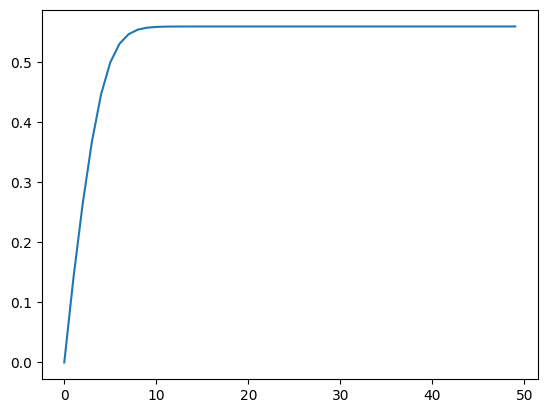

In [374]:
plt.plot(data)

In [352]:
np.array(actual)

array([0.1948166 , 0.29701278, 0.38623793, 0.46413837, 0.53215146,
       0.59153213, 0.64337604, 0.68863978, 0.72815851, 0.76266141,
       0.7927851 , 0.81908541, 0.84204761, 0.86209538, 0.87959862,
       0.89488031, 0.9082224 , 0.91987108, 0.93004127, 0.93892063,
       0.946673  , 0.95344142, 0.95935076, 0.96451008, 0.96901456,
       0.97294732, 0.97638093, 0.97937873, 0.98199604, 0.98428115,
       0.98627623, 0.98801809, 0.98953887, 0.99086663, 0.99202586,
       0.99303796, 0.9939216 , 0.99469309, 0.99536666, 0.99595474,
       0.99646817, 0.99691644, 0.99730782, 0.99764952, 0.99794785,
       0.99820831, 0.99843572, 0.99863426, 0.9988076 , 0.99895895])

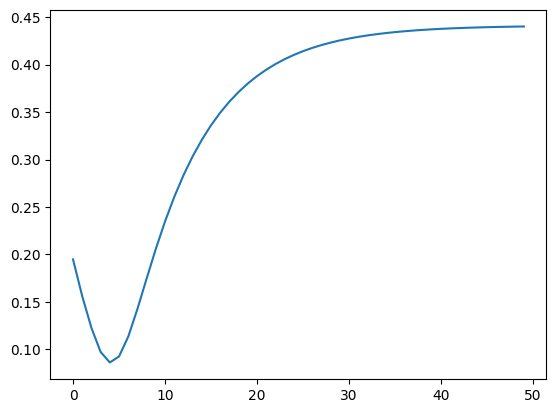

In [353]:
plt.plot(np.abs(np.array(data) - np.array(actual)))